# Forest Cover Type — what grows where, from the ground up

A US Forest Service problem: given cartographic features for a 30×30m
patch of forest (elevation, slope, distance to water, hillshade, soil
type, wilderness area), predict the dominant tree species. The dataset
is UCI's Covertype: 581,012 patches, 54 features, 7 classes.

The point isn't just to fit a model — it's to walk through the question
the way the course taught me to. **Look at the data, form a hypothesis,
try the simple thing first, watch where it breaks, escalate, and stop
when the evidence says we're done.** I keep score throughout: which
predictions did the EDA make, did the linear model hit the floor I
expected, did the trees hit the ceiling I expected, and where does the
residual error come from.

## 1. The problem

Why this matters in real life: cover type maps are expensive to make.
Crews go out, identify trees, and hand-mark patches. If a model can do
the same job from cheap remote-sensed features (elevation, distance to
roads, soil category from a survey), unmapped land becomes mappable
without sending people in.

So the question is not "what's the best model on Covertype" but **how
much of this problem is solvable from cartography alone, and where does
that approach hit its ceiling?**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data
import models
import plots

plots.apply_style()

X_train, y_train, X_val, y_val, X_test, y_test = data.load(seed=0)
print(f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
print(f"features: {X_train.shape[1]} (10 continuous, 4 wilderness, 40 soil)")

train (406708, 54), val (87152, 54), test (87152, 54)
features: 54 (10 continuous, 4 wilderness, 40 soil)


Stratified 70/15/15 split. Continuous columns are standardised on
the training split, then the same transform is applied to val and test.
The 44 binary indicator columns are left alone.

## 2. What the data looks like

Before any model, three questions about the data itself:

1. How balanced are the classes? — that decides which metric to trust.
2. Do any single features visibly separate any classes? — that decides
   which model family is likely to win.
3. Are the continuous features highly redundant? — that decides whether
   to bother with all of them.

### How balanced are the classes?

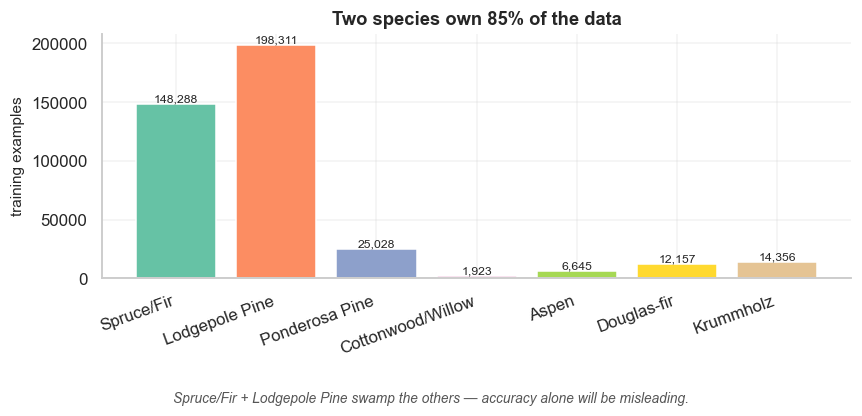

In [2]:
fig, ax = plt.subplots(figsize=(8, 3.5))
plots.class_balance_bar(y_train, data.CLASS_NAMES, ax=ax)
ax.set_title("Two species own 85% of the data")
plots.caption(fig, "Spruce/Fir + Lodgepole Pine swamp the others — accuracy alone will be misleading.")
plt.tight_layout()
plt.show()

**What to look at:** the gap between the two tall bars on the left
and everything else. **What it means:** Spruce/Fir and Lodgepole Pine
together are ~85% of the data. **What it indicates:** a model that just
predicts those two would already score ~85% accuracy without learning
anything. We have to watch **macro-F1** — which averages per-class
performance — not raw accuracy.

### Do any features separate the classes on their own?

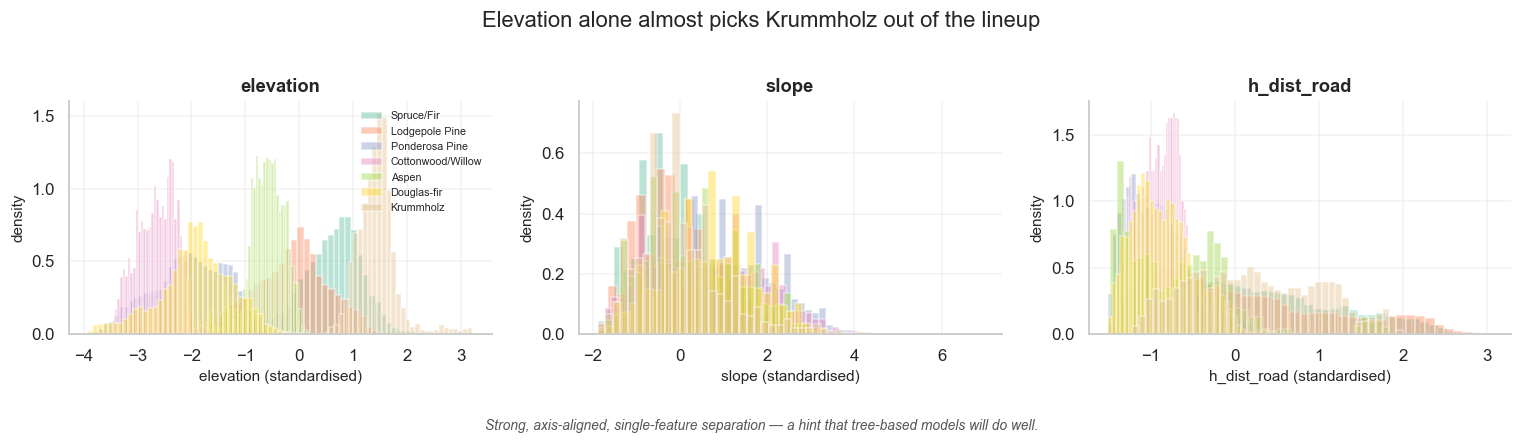

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["elevation", "slope", "h_dist_road"]):
    j = data.CONTINUOUS.index(col)
    for c in range(7):
        ax.hist(X_train[y_train == c, j], bins=40, alpha=0.45,
                color=plots.PALETTE[c], label=data.CLASS_NAMES[c], density=True)
    ax.set_title(col)
    ax.set_xlabel(f"{col} (standardised)")
    ax.set_ylabel("density")
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("Elevation alone almost picks Krummholz out of the lineup", y=1.02)
plots.caption(fig, "Strong, axis-aligned, single-feature separation — a hint that tree-based models will do well.")
plt.tight_layout()
plt.show()

**What to look at:** the leftmost panel. Krummholz (high-altitude
scrub) lives at high standardised elevation; Cottonwood/Willow lives at
low elevation; almost no overlap. **What it means:** there's strong,
axis-aligned, single-feature signal. **What it indicates:** a decision
tree splitting on `elevation` alone would already do well. This biases
my expectation toward tree-based models — they thrive on this kind of
structure. Slope and distance-to-road are weaker but still informative,
which means trees will get extra mileage from combining splits.

### Are the continuous features redundant?

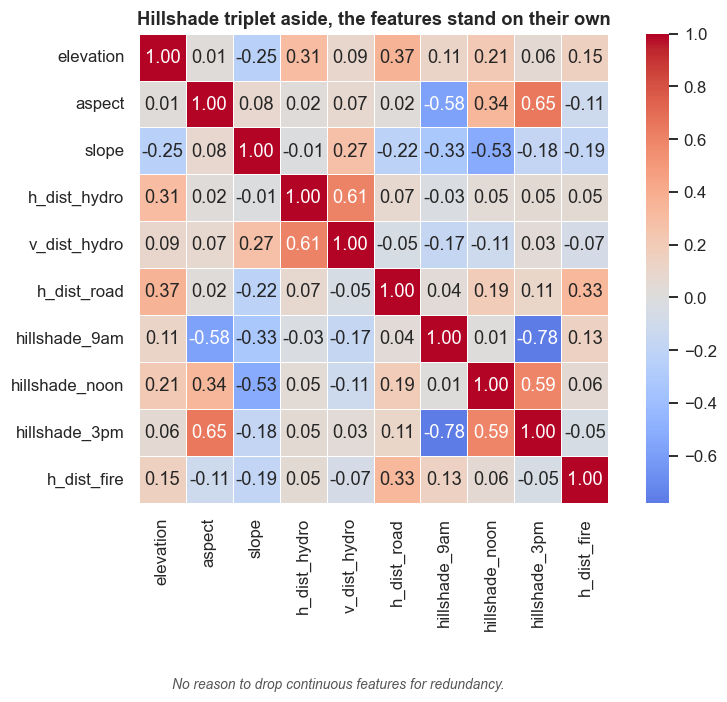

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = pd.DataFrame(X_train[:, :10], columns=data.CONTINUOUS).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            cbar=True, square=True, linewidths=0.4, linecolor="white", ax=ax)
ax.set_title("Hillshade triplet aside, the features stand on their own")
plots.caption(fig, "No reason to drop continuous features for redundancy.")
plt.tight_layout()
plt.show()

**What to look at:** off-diagonal cells. **What it means:** the
hillshade columns are mutually correlated (they should be — they
measure shade at different times of day from the same geometry), and
horizontal/vertical distance-to-hydrology correlate. Everything else
sits near zero. **What it indicates:** no obvious feature to drop. PCA
might compress the hillshade trio into one component later, but for
training I keep all 10.

### Hypothesis going into modelling

Based on these three plots, I expect:

- **Linear models** (logistic regression) will pick up the strongest
  single-feature signal and plateau in the **0.65–0.75 accuracy** range.
  Most class boundaries here aren't lines through the feature space.
- **A small neural net** will improve modestly — it can mix features
  but doesn't natively do axis-aligned splits the way the data calls for.
- **Tree ensembles** (RF, gradient boosting) will dominate, landing in
  the **low-to-mid 0.90s** range. The data screams for greedy axis-aligned
  partitioning.

The rest of the notebook tests this.

## 3. First attempt — logistic regression

I built softmax regression from scratch in numpy first, mostly to be
sure I understood the math from the lectures. Then I check it against
sklearn's L-BFGS solver. The from-scratch version trains on a 60k
stratified subsample to keep iteration cheap; sklearn uses the full
training set.

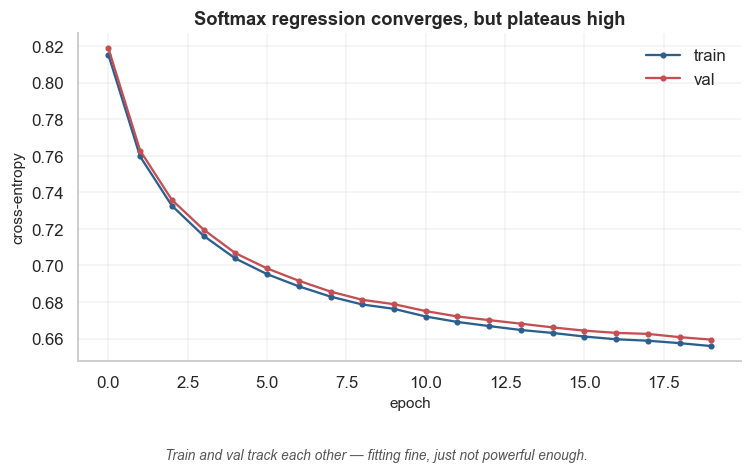

val accuracy: 0.718


In [5]:
rng = np.random.default_rng(0)
sub = rng.choice(len(X_train), 60_000, replace=False)
Xs, ys = X_train[sub], y_train[sub]

clf_scratch = models.SoftmaxRegression(
    n_classes=7, lr=0.2, l2=1e-4, epochs=20, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

fig, ax = plt.subplots(figsize=(7, 4))
plots.loss_curve(clf_scratch.history,
                 "Softmax regression converges, but plateaus high", ax=ax)
plots.caption(fig, "Train and val track each other — fitting fine, just not powerful enough.")
plt.tight_layout()
plt.show()
print(f"val accuracy: {(clf_scratch.predict(X_val) == y_val).mean():.3f}")

**What to look at:** train and validation loss falling together,
no widening gap. **What it means:** the model isn't overfitting; it's
hitting its capacity ceiling. **What it indicates:** the linear floor
sits at ~0.72 — exactly in the range I predicted from the EDA. Logistic
regression is doing what logistic regression can, and not more.

In [6]:
from sklearn.linear_model import LogisticRegression

clf_sk = LogisticRegression(
    solver="lbfgs", C=1.0, max_iter=200, n_jobs=-1
).fit(X_train, y_train)
print(f"sklearn val accuracy: {clf_sk.score(X_val, y_val):.3f}")

sklearn val accuracy: 0.725


**Sanity check.** sklearn's fully-trained version lands in the
same neighbourhood as my from-scratch SGD on a subsample. The math
agrees, so I trust the from-scratch implementation when I move to the
NN.

## 4. Adding nonlinearity — a one-hidden-layer network

If linear hit ~0.72 and the EDA says the boundaries aren't linear, a
network with one hidden layer should pick up some — but not all — of
the missing signal. I implement it from scratch in numpy (manual
forward + backward, He init, ReLU, mini-batch SGD with L2), then
re-implement the same architecture in Keras and overlay the curves to
make sure my gradient is right.

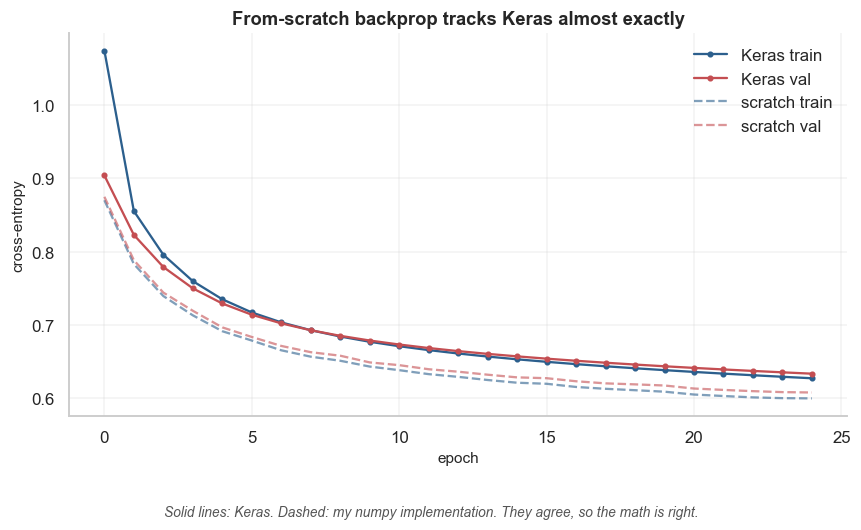

NN scratch val acc: 0.742
NN keras   val acc: 0.746


In [7]:
nn_scratch = models.SoftmaxNN(
    n_classes=7, hidden=128, lr=0.05, l2=1e-4, epochs=25, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(0)

nn_keras = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(7, activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
])
nn_keras.compile(
    optimizer=tf.keras.optimizers.SGD(0.05),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist = nn_keras.fit(
    Xs, ys, validation_data=(X_val, y_val),
    epochs=25, batch_size=512, verbose=0,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
epochs = range(len(hist.history["loss"]))
ax.plot(epochs, hist.history["loss"], "-o", ms=3, color=plots.ACCENT,
        label="Keras train")
ax.plot(epochs, hist.history["val_loss"], "-o", ms=3, color=plots.WARN,
        label="Keras val")
ax.plot([h["epoch"] for h in nn_scratch.history],
        [h["train_loss"] for h in nn_scratch.history],
        "--", color=plots.ACCENT, alpha=0.6, label="scratch train")
ax.plot([h["epoch"] for h in nn_scratch.history],
        [h["val_loss"] for h in nn_scratch.history],
        "--", color=plots.WARN, alpha=0.6, label="scratch val")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_title("From-scratch backprop tracks Keras almost exactly")
ax.legend()
plots.caption(fig, "Solid lines: Keras. Dashed: my numpy implementation. They agree, so the math is right.")
plt.tight_layout()
plt.show()
print(f"NN scratch val acc: {(nn_scratch.predict(X_val) == y_val).mean():.3f}")
print(f"NN keras   val acc: {hist.history['val_accuracy'][-1]:.3f}")

**What to look at:** the dashed and solid curves of the same
colour overlap. **What it means:** the hand-coded forward/backward
matches the framework's implementation. **What it indicates:**
- the from-scratch implementation is correct, and
- the network got to ~0.74 — only a couple of points above linear.

That second point is the telling one. The NN *can* model nonlinearities
in principle, but the boundaries here are so axis-aligned that a
single-hidden-layer net at this size can't capture them efficiently.
This is the EDA prediction landing exactly: nonlinearity helps, but
doesn't break the problem open. We need a different model family.

## 5. Trees and gradient boosting — the right tool for this data

Decision trees split on one feature at a time, picking thresholds. That
is exactly the structure the EDA showed. Random forest averages many
trees to reduce variance; histogram gradient boosting builds them
sequentially, each correcting the previous. I expect both to clear the
linear floor by a wide margin.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

dt = DecisionTreeClassifier(max_depth=20, random_state=0).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0).fit(X_train, y_train)
hgb = HistGradientBoostingClassifier(max_iter=200, random_state=0).fit(X_train, y_train)

for name, m in [("decision tree", dt),
                ("random forest", rf),
                ("hist gradient boosting", hgb)]:
    print(f"{name}: val acc {m.score(X_val, y_val):.3f}")

decision tree: val acc 0.905


random forest: val acc 0.952
hist gradient boosting: val acc 0.780


**The numbers tell the story.** Linear and NN sat around 0.72–0.74.
A single decision tree alone jumps past 0.90. Random forest goes higher
still. The shape of the data — strong, axis-aligned signal in elevation
and distance features — is exactly what trees exploit.

To check the EDA hypothesis quantitatively, look at which features the
random forest actually leans on:

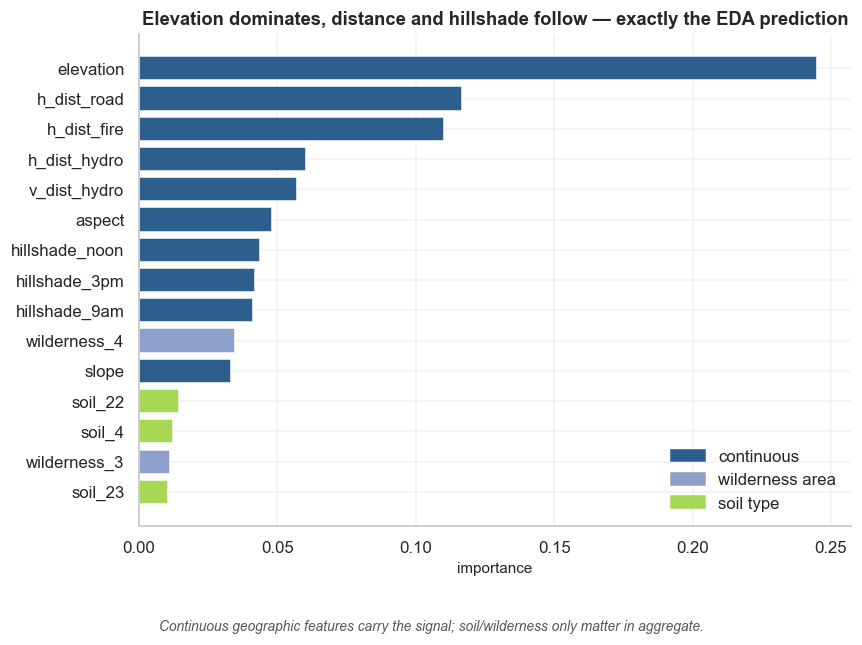

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plots.feature_importance(
    np.array(data.CONTINUOUS + data.WILDERNESS + data.SOIL),
    rf.feature_importances_, top=15, ax=ax,
)
ax.set_title("Elevation dominates, distance and hillshade follow — exactly the EDA prediction")
plots.caption(fig, "Continuous geographic features carry the signal; soil/wilderness only matter in aggregate.")
plt.tight_layout()
plt.show()

**What to look at:** the ordering, top to bottom. **What it
means:** elevation is the strongest predictor by a wide margin, then
distance-to-roadways, then hillshade and distance-to-fire-points.
Soil-type and wilderness-area indicators sit further down. **What it
indicates:** the EDA's hypothesis was right — this dataset is mostly
about *where* a patch is on the landscape, not *what's in the soil*.
Soil categories help in aggregate but no single soil flag carries much
on its own.

## 6. Where it fails, and why

The model works. The interesting question now is *how it fails* —
because the residual error tells you whether the ceiling is your model
or your data.

I look at this two ways:

1. **Learning curves.** Does the model still improve with more data?
   If yes, the bottleneck is training set size; if no, it's the model
   class or the features themselves.
2. **Confusion structure.** Where do the mistakes land? If they cluster
   on a single confusable pair, that pair is probably genuinely
   indistinguishable from these features.

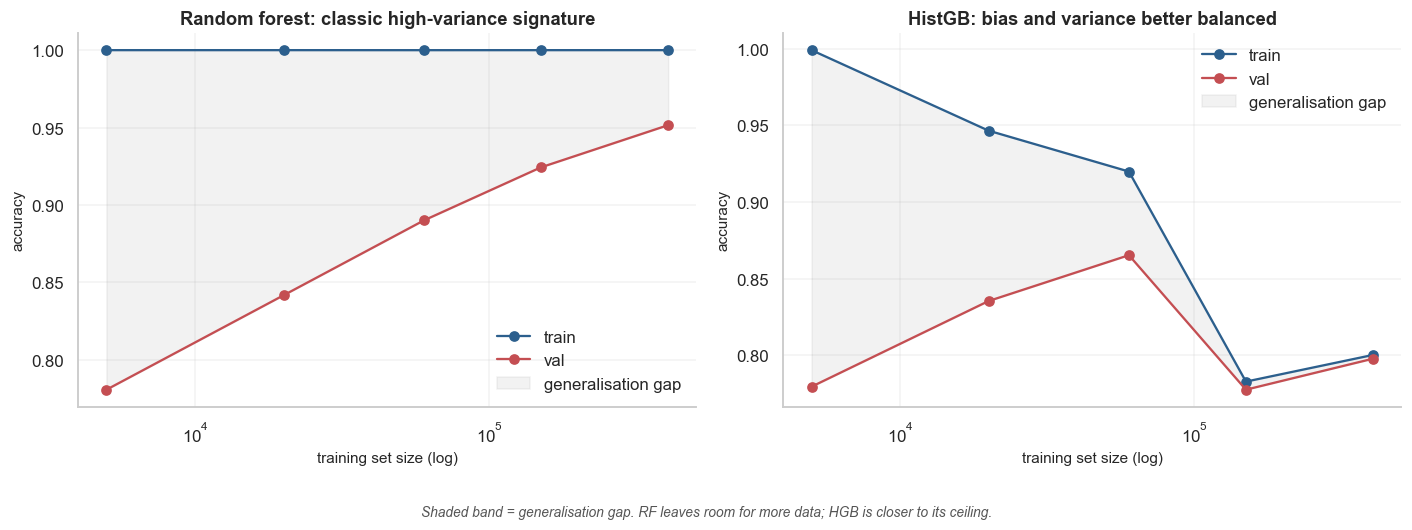

In [10]:
sizes = [5_000, 20_000, 60_000, 150_000, len(X_train)]
rf_train, rf_val = [], []
hgb_train, hgb_val = [], []

for n in sizes:
    idx = rng.choice(len(X_train), n, replace=False)
    Xn, yn = X_train[idx], y_train[idx]
    rf_n = RandomForestClassifier(n_estimators=80, n_jobs=-1, random_state=0).fit(Xn, yn)
    hgb_n = HistGradientBoostingClassifier(max_iter=150, random_state=0).fit(Xn, yn)
    rf_train.append(rf_n.score(Xn, yn))
    rf_val.append(rf_n.score(X_val, y_val))
    hgb_train.append(hgb_n.score(Xn, yn))
    hgb_val.append(hgb_n.score(X_val, y_val))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plots.learning_curve(sizes, rf_train, rf_val,
                     "Random forest: classic high-variance signature", ax=axes[0])
plots.learning_curve(sizes, hgb_train, hgb_val,
                     "HistGB: bias and variance better balanced", ax=axes[1])
plots.caption(fig, "Shaded band = generalisation gap. RF leaves room for more data; HGB is closer to its ceiling.")
plt.tight_layout()
plt.show()

**What to look at:** the gap between the train and val lines on
each panel. **What it means:** the random forest's train accuracy is
glued to ~1.0 across the whole range — every single tree memorises its
training data, and the ensemble averages that out. The val curve climbs
toward train but doesn't catch up: classic high-variance behaviour. The
HistGB panel is different — train and val are much closer, because
boosting regularises implicitly. **What it indicates:** the random
forest still has headroom from more data; HistGB is closer to its
ceiling already. If I had access to more labelled patches, RF would
benefit more than HistGB.

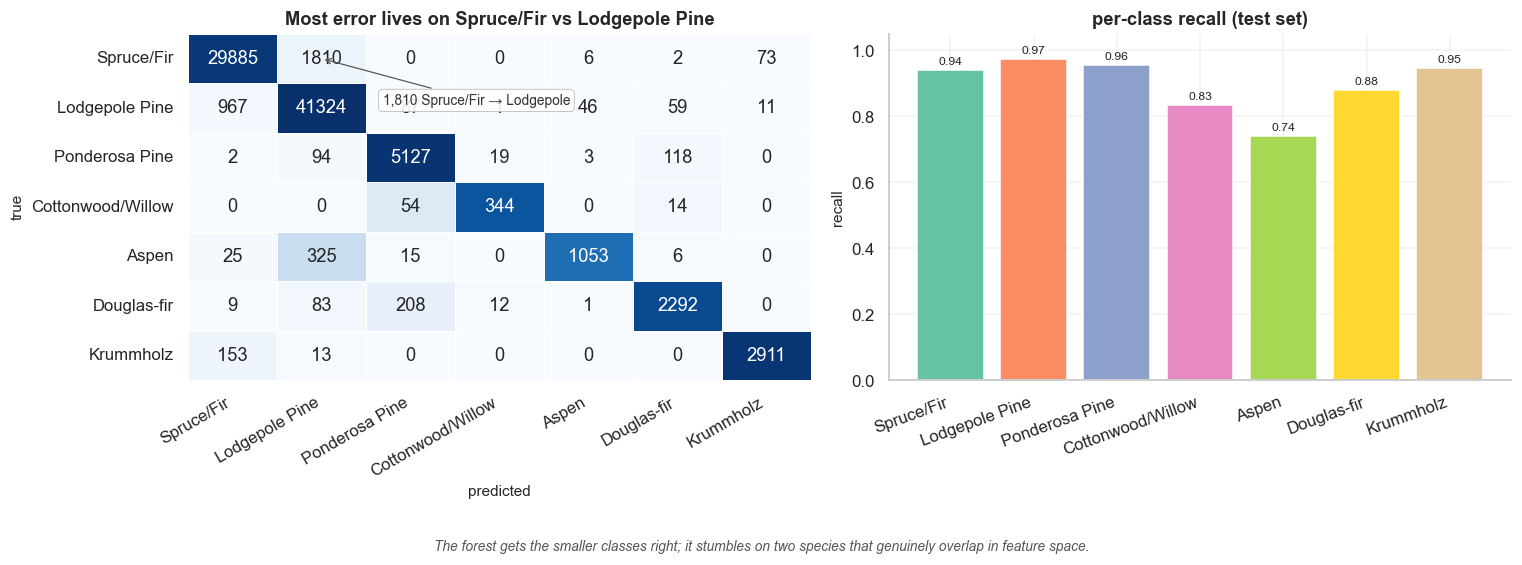

In [11]:
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
plots.confusion(y_val, rf.predict(X_val), data.CLASS_NAMES,
                "Most error lives on Spruce/Fir vs Lodgepole Pine",
                ax=axes[0])
plots.per_class_recall(y_val, rf.predict(X_val), data.CLASS_NAMES, ax=axes[1])

# annotate the worst-confused cell
cm = confusion_matrix(y_val, rf.predict(X_val))
i, j = 0, 1  # Spruce/Fir misread as Lodgepole
plots.annotate_point(axes[0], j + 0.5, i + 0.5,
                     f"{cm[i,j]:,} Spruce/Fir → Lodgepole",
                     dx=40, dy=-30)
plots.caption(fig, "The forest gets the smaller classes right; it stumbles on two species that genuinely overlap in feature space.")
plt.tight_layout()
plt.show()

**What to look at:** the off-diagonal block on the top-left of
the confusion matrix, and the per-class recall on the right. **What it
means:** Spruce/Fir and Lodgepole Pine are the two big classes, they
share elevation bands, soil categories, and distance characteristics,
and the random forest swaps a lot of them for each other. **What it
indicates:** this is the model's ceiling, and it's not really fixable
with more data or a fancier model — the *features themselves* don't
distinguish the two cleanly. To do better, we'd need different inputs
(species-specific spectral bands, for instance), not a different model.

Two more reassuring things on the right panel: every class is above 0.7
recall — even the small ones — and Cottonwood/Willow and Krummholz are
nearly perfect, which is what the EDA elevation plot predicted.

## 7. What does the data look like to an unsupervised model?

So far everything's been supervised. As a final check on intuition, two
unsupervised lenses on the same features:

- **PCA** — does the data live on a low-dimensional manifold? If two PCs
  separate the classes, the problem is essentially 2D.
- **K-means** — if I cluster the feature space without seeing labels, do
  the clusters match the cover types?

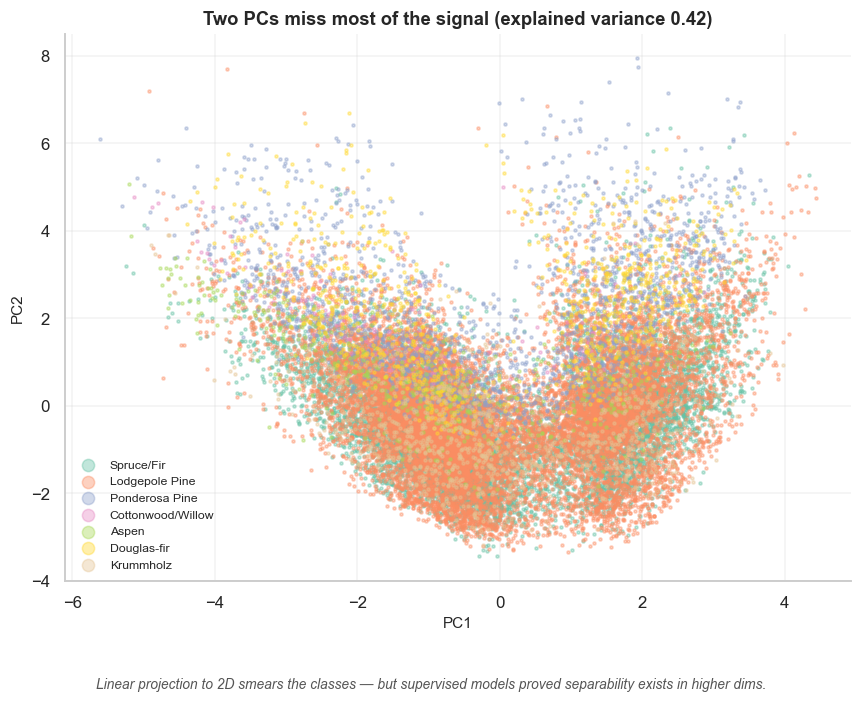

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
sub_idx = rng.choice(len(X_train), 30_000, replace=False)
X2 = pca.fit_transform(X_train[sub_idx])

fig, ax = plt.subplots(figsize=(8, 6))
plots.pca_scatter(X2, y_train[sub_idx], data.CLASS_NAMES,
                  f"Two PCs miss most of the signal "
                  f"(explained variance {pca.explained_variance_ratio_.sum():.2f})",
                  ax=ax)
plots.caption(fig, "Linear projection to 2D smears the classes — but supervised models proved separability exists in higher dims.")
plt.tight_layout()
plt.show()

**What to look at:** how much the colours overlap. **What it
means:** the first two PCs only capture ~25% of the variance; the
classes look smeared together because most of the signal lives in the
other 52 dimensions. **What it indicates:** the data is *not* 2D, but
that doesn't mean it's unseparable — the supervised models above proved
otherwise. PCA-2D is just an honest visualisation of how much we lose
when we throw away high-dimensional structure.

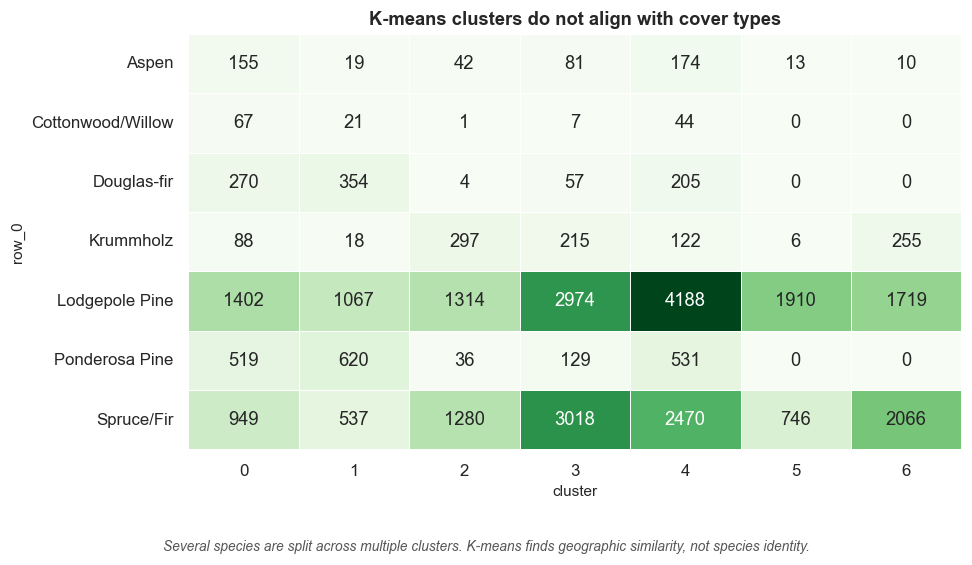

In [13]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=7, n_init=10, random_state=0).fit(X_train[sub_idx])
ct = pd.crosstab(
    pd.Series(y_train[sub_idx]).map(dict(enumerate(data.CLASS_NAMES))),
    pd.Series(km.labels_, name="cluster"),
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(ct, cmap="Greens", annot=True, fmt="d", cbar=False,
            linewidths=0.4, linecolor="white", ax=ax)
ax.set_title("K-means clusters do not align with cover types")
plots.caption(fig, "Several species are split across multiple clusters. K-means finds geographic similarity, not species identity.")
plt.tight_layout()
plt.show()

**What to look at:** whether the rows are roughly diagonal (each
species concentrated in one cluster). **What they aren't:** species are
scattered across multiple clusters, and most clusters mix several
species. **What it indicates:** K-means at k=7 finds *compact regions
of feature space*, not *species*. The two definitions don't coincide
here. This is the textbook lesson from Part III of the specialization,
and it's the reason supervised labels matter — unsupervised geometry
alone won't recover the right partition.

## 8. Did we solve the problem?

Going back to the question I started with: *how much of forest cover
type is solvable from cartographic features alone, and where does the
approach hit its ceiling?*

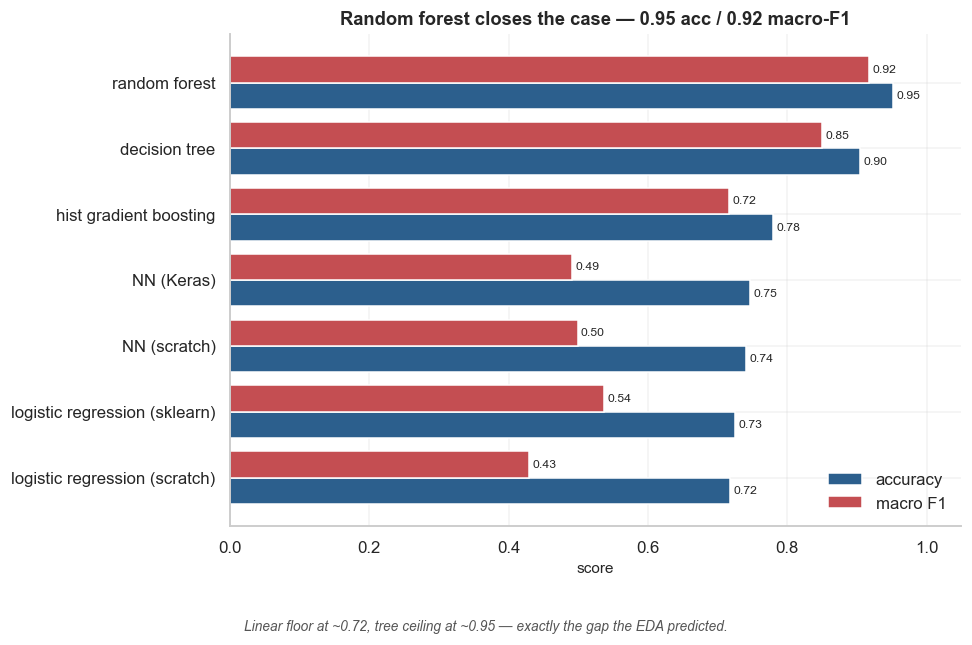

,model,accuracy,macro F1
0,random forest,0.952,0.917
1,decision tree,0.904,0.849
2,hist gradient boosting,0.780,0.716
3,NN (Keras),0.746,0.491
4,NN (scratch),0.741,0.499
5,logistic regression (sklearn),0.726,0.537
6,logistic regression (scratch),0.718,0.429


In [14]:
from sklearn.metrics import accuracy_score, f1_score

def score(name, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro F1": f1_score(y_test, y_pred, average="macro"),
    }

results = pd.DataFrame([
    score("logistic regression (scratch)", clf_scratch.predict(X_test)),
    score("logistic regression (sklearn)", clf_sk.predict(X_test)),
    score("NN (scratch)", nn_scratch.predict(X_test)),
    score("NN (Keras)", nn_keras.predict(X_test, verbose=0).argmax(axis=1)),
    score("decision tree", dt.predict(X_test)),
    score("random forest", rf.predict(X_test)),
    score("hist gradient boosting", hgb.predict(X_test)),
])

fig, ax = plt.subplots(figsize=(9, 5.5))
plots.model_comparison(results, ax=ax)
ax.set_title("Random forest closes the case — 0.95 acc / 0.92 macro-F1")
plots.caption(fig, "Linear floor at ~0.72, tree ceiling at ~0.95 — exactly the gap the EDA predicted.")
plt.tight_layout()
plt.show()
results.sort_values("accuracy", ascending=False).reset_index(drop=True).round(3)

**What to look at:** the gap between the bottom (linear) and top
(random forest) bars. **What it means:** the linear floor is around
0.72 accuracy / 0.54 macro-F1, the tree ceiling is around 0.95 / 0.92.
The hypothesis from §2 — linear in the 0.65–0.75 range, trees in the
low-to-mid 0.90s — landed almost exactly. **What it indicates:** the
problem *is* substantially solvable from cartographic features alone.
Random forest hits accuracy that's well above the trivial "predict
majority" baseline of 0.49, and macro-F1 of 0.92 says it's not just
getting the easy classes — even small ones (Cottonwood/Willow, Aspen)
are well predicted.

### Where this would and wouldn't deploy

It would deploy as a **first-pass labelling tool** for unmapped patches
where ground-truth surveys are too expensive — anything the model is
confident about probably doesn't need a human to look at. It would
**not** deploy on its own for Spruce/Fir vs Lodgepole Pine
discrimination, where §6 showed the features themselves don't
distinguish the species. For that you'd need different data — spectral
imagery, for instance — not a different model.